In [502]:
# to autoimport edited modules in the notebook
%load_ext autoreload
%autoreload 2
%pip install -r requirements.txt

from grsc_cb.model import GRSC_CB_Model
from grsc_cb.instance import GRSC_CB_Instance
import numpy as np
import networkx as nx
from grsc_cb.reserve_graph import Graph

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [503]:
# number of land parcels
n = 100
# number of species
m = 40
# number of max connected areas
k = 1
# range of habitat suitability function
w_min, w_max = 20, 100
# range of costs
c_min, c_max = 1, 100
# lambda percentage threshold
lambda_threshold = 0.05
# buffer size
d = 1
# tau threshold
tau = 0.8

External nodes: [98, 11, 13, 78, 80, 18, 51, 84, 54, 88, 27, 93, 95]


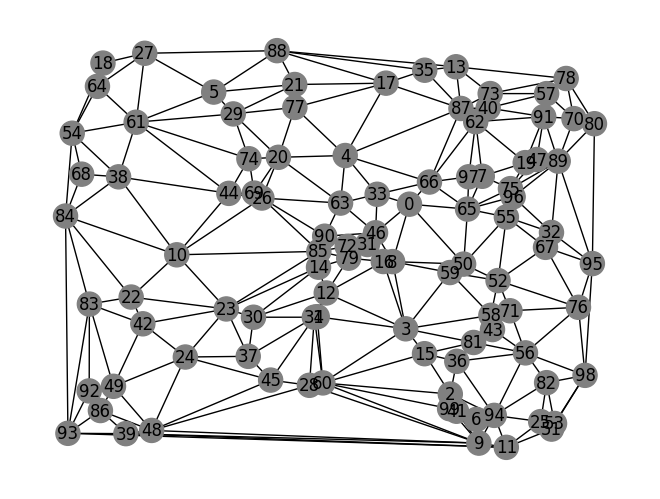

In [504]:
# generate a random instance Delunay graph
G = Graph.random_delaunay(n)
G.draw_graph(with_labels=True)
external_nodes = G.external_nodes()
print(f"External nodes: {external_nodes}")

In [505]:
# costs of land parcels
c = {i: np.random.randint(c_min, c_max + 1) for i in G.nodes}

In [506]:
# specie definition
S_1 = list(range(m//3))
S_2 = list(range(m//3, m))
P_1 = len(S_1)
P_2 = len(S_2)

# habitat suitability score function
w = {}
for s in S_1 + S_2:
    prob_zero = 0.2 if s in S_1 else 0.1
    for i in G.nodes:
        if i in external_nodes and s in S_1:
            w[(i, s)] = 0
        elif np.random.rand() < prob_zero:
            w[(i, s)] = 0
        else:
            w[(i, s)] = np.random.randint(w_min, w_max + 1)
            
# suitability quota
lambda_s = {s: lambda_threshold * sum(w[(i, s)] for i in G.nodes) for s in S_1 + S_2}

In [507]:
# toy instance
instance = GRSC_CB_Instance(G, 
                            S_1, S_2, P_1, P_2, 
                            k, w, lambda_s, c, tau, d)


GRSC_CB_Instance(|V|=100, |E|=376, |S1|=13, |S2|=27, P1=13, P2=27, k=1, d=1)
Status: 2 Optimal
Nodes in the reserve (x): [19, 24, 35, 55, 67, 92]
Nodes in the core (z): [19, 24, 35, 55, 67, 92]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Objective: 6.0


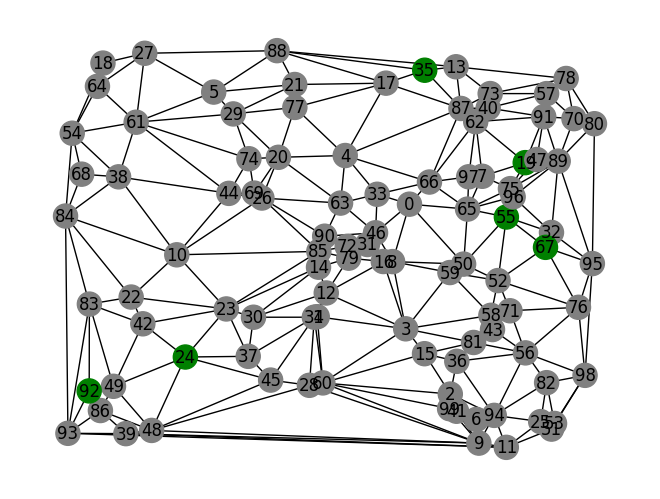

In [516]:
print(instance)
model = GRSC_CB_Model(instance, simple=True, B=False, C=False)
model.solve()
model.print_solution(with_labels=True)

GRSC_CB_Instance(|V|=100, |E|=376, |S1|=13, |S2|=27, P1=13, P2=27, k=1, d=1)
Status: 2 Optimal
Nodes in the reserve (x): [4, 9, 15, 21, 25, 47, 96]
Nodes in the core (z): [4, 9, 15, 21, 25, 96]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Objective: 28.0


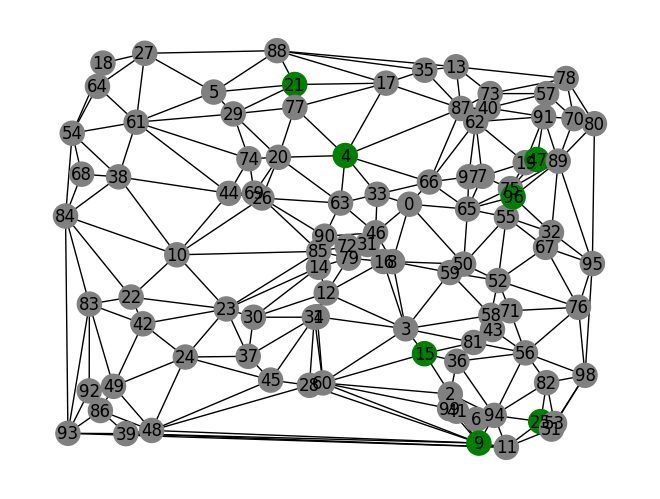

In [517]:
print(instance)
model = GRSC_CB_Model(instance, B=False, C=False)
model.solve()
model.print_solution(with_labels=True)

GRSC_CB_Instance(|V|=100, |E|=376, |S1|=13, |S2|=27, P1=13, P2=27, k=1, d=1)
Status: 2 Optimal
Nodes in the reserve (x): [2, 6, 9, 15, 19, 32, 36, 41, 47, 60, 70, 75, 80, 89, 91, 94, 95, 96, 99]
Nodes in the core (z): [2, 6, 41, 47, 89, 99]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Objective: 449.0


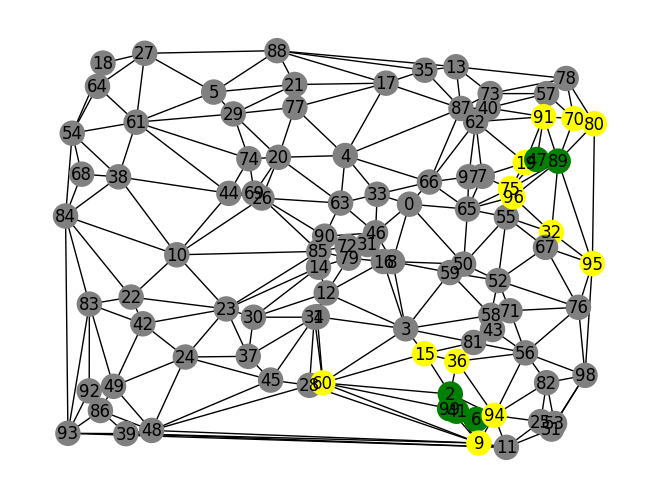

In [518]:
print(instance)
model = GRSC_CB_Model(instance, C=False)
model.solve()
model.print_solution(with_labels=True)

GRSC_CB_Instance(|V|=100, |E|=376, |S1|=13, |S2|=27, P1=13, P2=27, k=1, d=1)
Status: 2 Optimal
Nodes in the reserve (x): [9, 39, 41, 45, 48, 60, 93, 99]
Nodes in the core (z): [9, 39, 41, 45, 48, 60, 99]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
r-arc-node separators (y): [9]
Objective: 139.0


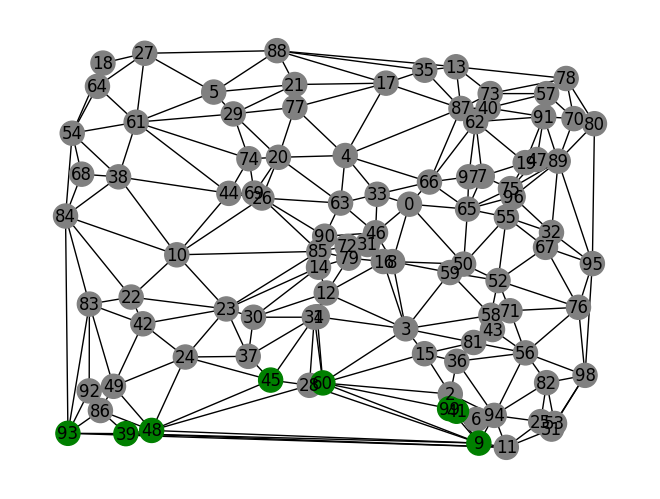

In [519]:
print(instance)
model = GRSC_CB_Model(instance, B=False)
model.solve()
model.print_solution(with_labels=True)

GRSC_CB_Instance(|V|=100, |E|=376, |S1|=13, |S2|=27, P1=13, P2=27, k=1, d=1)
Status: 2 Optimal
Nodes in the reserve (x): [1, 2, 3, 6, 9, 12, 15, 28, 34, 36, 41, 60, 94, 99]
Nodes in the core (z): [1, 2, 6, 41, 60, 99]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
r-arc-node separators (y): [1]
Objective: 502.0


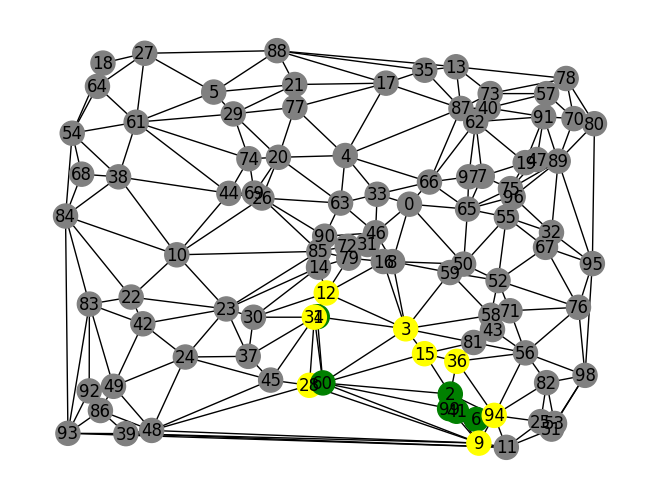

In [520]:
print(instance)
model = GRSC_CB_Model(instance)
result = model.solve()
model.print_solution(with_labels=True)

GRSC_CB_Instance(|V|=100, |E|=376, |S1|=13, |S2|=27, P1=13, P2=27, k=1, d=1)
Status: 2 Optimal
Nodes in the reserve (x): [1, 2, 3, 6, 9, 12, 15, 28, 34, 36, 41, 60, 94, 99]
Nodes in the core (z): [1, 2, 6, 41, 60, 99]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
r-arc-node separators (y): [1]
Objective: 502.0


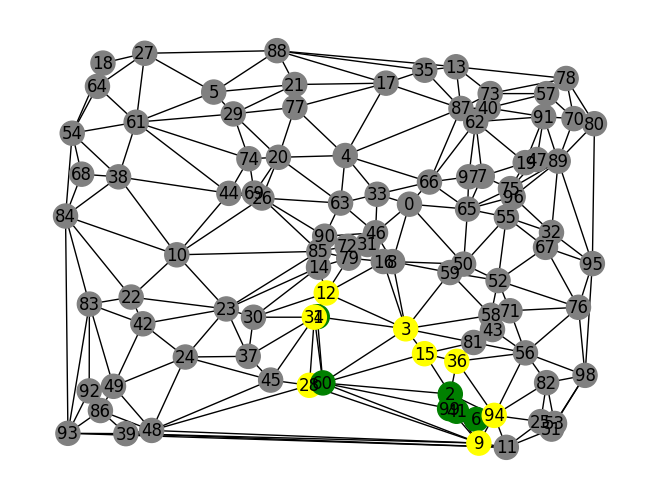

In [521]:
print(instance)
model = GRSC_CB_Model(instance)
result = model.solve(cp_heuristic=True)
model.print_solution(with_labels=True)

GRSC_CB_Instance(|V|=100, |E|=376, |S1|=13, |S2|=27, P1=13, P2=27, k=1, d=1)
Status: 2 Optimal
Nodes in the reserve (x): [1, 2, 3, 6, 9, 12, 15, 28, 34, 36, 41, 60, 94, 99]
Nodes in the core (z): [1, 2, 6, 41, 60, 99]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
r-arc-node separators (y): [2]
Objective: 502.0


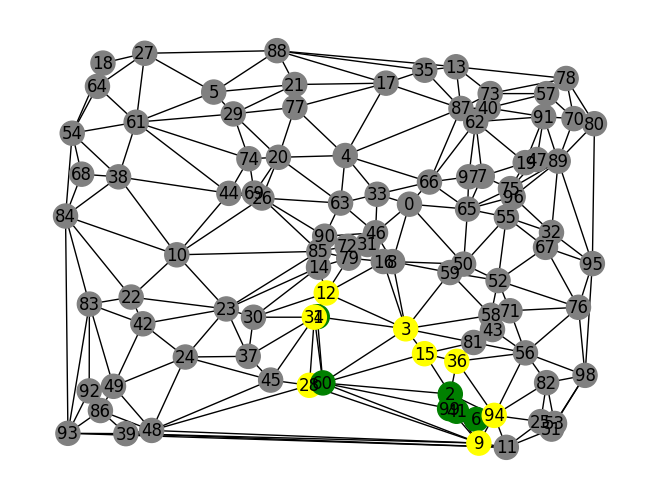

In [523]:
print(instance)
model = GRSC_CB_Model(instance)
result = model.solve(cp_heuristic=True, lb_heuristic=True)
model.print_solution(with_labels=True)